In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from utils import *
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
def barplot_annotate_brackets(num1, num2, data, center, height, ax, yerr=None, dh=.05, barh=.05, fs=None, maxasterix=None):
    """ 
    Annotate barplot with p-values. 
    Adapted from the provided script.
    """
    if type(data) is str:
        text = data
    else:
        if data > 0.05:
          return
        text = ''
        p = .05
        while data < p:
            text += '*'
            p /= 10.
            if maxasterix and len(text) == maxasterix:
                break
        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    if yerr:
        ly += yerr[num1]
        ry += yerr[num2]

    ax_y0, ax_y1 = plt.gca().get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)

    y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)

    ax.plot(barx, bary, c='black')

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    ax.text(*mid, text, **kwargs)

In [134]:
import numpy as np

def holm_bonferroni(pvals):
    pvals = np.asarray(pvals)
    n = len(pvals)

    order = np.argsort(pvals)
    ranked = pvals[order]

    adj = (n - np.arange(n)) * ranked
    adj = np.maximum.accumulate(adj)  # enforce monotonicity
    adj = np.clip(adj, 0, 1)

    pvals_adj = np.empty_like(adj)
    pvals_adj[order] = adj #reorder to original order
    return pvals_adj

def cliffs_delta(u_stat, n_A, n_B):
     # Compute_cliff_delta:
    U1 = u_stat
    U2 = n_A * n_B - U1

    # Cliff’s delta must use U1 (vals_A vs vals_B)
    cliffs_d = (U1 - U2) / (n_A * n_B)
    # Interpretation (Romano et al., 2006)
    abs_d = abs(cliffs_d)
    if abs_d < 0.147:
        effect = "Negligible"
    elif abs_d < 0.33:
        effect = "Small"
    elif abs_d < 0.474:
        effect = "Medium"
    else:
        effect = "Large"
        
    # print(f"Cliff's Delta: {cliffs_d:.3f} ({effect})")

    return (cliffs_d,effect)

In [4]:
center="peak"
WINDOW_MS=100
filename=f"power_analysis_results_center_{center}_{WINDOW_MS}ms.pkl"
filename_properties=f"power_analysis_properties_center_{center}_{WINDOW_MS}ms.csv"

In [5]:
# Setup paths
curr_dir = os.getcwd()
# Assuming the notebook is in snnTorch/generalization_madrid
SPIKES_ROOT = os.path.join(curr_dir, "data")

DATA_FILE = os.path.join(SPIKES_ROOT, filename)

print(f"Looking for data at: {DATA_FILE}")

if not os.path.exists(DATA_FILE):
    print("Data file not found. Please run power_analysis.py first.")
else:
    with open(DATA_FILE, 'rb') as f:
        all_power_data = pickle.load(f)
    print(f"Loaded data for keys: {list(all_power_data.keys())}")

Looking for data at: c:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples\snnTorch\generalization_madrid\data\power_analysis_results_center_peak_100ms.pkl
Loaded data for keys: [('adapt20_3b', 20), ('dsb4updn_median_200_11b', 20), ('dsb4updn_median_200_11f', 20), ('dsb4updn_median_200_12b', 20), ('dsb4updn_median_200_13f', 20), ('dsb4updn_median_200_14b', 20), ('dsb4updn_median_200_15f', 20), ('dsb4updn_median_200_16b', 20), ('dsb4updn_median_200_9f', 20), ('updnb4ds_100_13b', 20), ('updnb4ds_100_13f', 20), ('updnb4ds_100_7', 20)]


In [6]:
freq=10000 # Define frequency variable
cut_snippets=50 # Define cut_snippets variable (ms)
def prepare_dataframe(all_power_data):
    records = []
    
    for (network, adapt), events in all_power_data.items():
        for event_type in ['TP', 'FP', 'FN']:
            snippets = events[event_type]
            for s in snippets:
                if len(s) == 0: continue
                # Trim snippets
                s = s[cut_snippets*freq//1000 : -cut_snippets*freq//1000]
                # Calculate metrics
                peak_power = np.max(s)
                mean_power = np.mean(s)
                
                records.append({
                    'Network': network,
                    'Adapt': adapt,
                    'Type': event_type,
                    'Peak Power': peak_power,
                    'Mean Power': mean_power,
                    'Trace': s
                })
    
    return pd.DataFrame(records)

if os.path.exists(DATA_FILE):
    df = prepare_dataframe(all_power_data)
    print(f"Created DataFrame with {len(df)} records")
    display(df.head())

Created DataFrame with 36784 records


,Network,Adapt,Type,Peak Power,Mean Power,Trace
0,adapt20_3b,20,TP,2.041693,0.447155,"[0.8404406213782437, 0.8375343692801409, 0.833..."
1,adapt20_3b,20,TP,2.080786,0.347155,"[0.5441486142153137, 0.5686957771860557, 0.590..."
2,adapt20_3b,20,TP,5.809756,1.319391,"[-0.45534571639668475, -0.4485797768945298, -0..."
3,adapt20_3b,20,TP,2.516075,0.223163,"[-0.7014316717351148, -0.7012360205266145, -0...."
4,adapt20_3b,20,TP,7.403191,2.868911,"[3.3218393247733227, 3.3884970068591422, 3.450..."


In [10]:
stats_df=df.copy()
measures=['Peak Power', 'Mean Power']

# Create a summary table with mean, std, and count for each measure
summary_table = stats_df.groupby("Type")[measures].agg(['mean', 'median','std', 'count']).round(2)

display(summary_table)

Peak Power                     Mean Power                    
           mean median   std  count       mean median   std  count
Type                                                              
FN         3.26   2.52  2.93   6405       0.80   0.44  1.23   6405
FP         4.06   3.28  3.19  15040       0.91   0.61  1.16  15040
TP         4.68   3.75  3.74  15339       1.31   0.93  1.52  15339

In [136]:
from scipy.stats import mannwhitneyu

def plot_power(vtype="Peak Power"):
    if not os.path.exists(DATA_FILE) or df.empty:
        return

    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Define order for consistency
    order = ['TP', 'FP', 'FN']
    colors = {'TP': 'green', 'FP': 'red', 'FN': 'blue'}
    
    # Aggregate plot
    sns.violinplot(data=df, x='Type', y=vtype, order=order, inner="quartile", ax=ax, palette=colors, alpha=0.3, linecolor="black", linewidth=1.4)
    # sns.stripplot(data=df, x='Type', y=vtype, order=order, ax=ax, color="black", alpha=0.2, jitter=True, s=3)
    
    # Statistical testing
    print(f"Statistical Significance (Mann-Whitney U Test) - {vtype}:")
    
    # Get distributions
    tp_vals = df[df['Type'] == 'TP'][vtype]
    fp_vals = df[df['Type'] == 'FP'][vtype]
    fn_vals = df[df['Type'] == 'FN'][vtype]
    
    # Prepare heights and centers for annotation
    max_tp = tp_vals.max() if not tp_vals.empty else 0
    max_fp = fp_vals.max() if not fp_vals.empty else 0
    max_fn = fn_vals.max() if not fn_vals.empty else 0
    
    heights = [max_tp, max_fp, max_fn]
    centers = [0, 1, 2]

    p_vals = []
    comparisons = []

    # Compare TP (0) vs FP (1)
    if len(tp_vals) > 0 and len(fp_vals) > 0:
        stat, p = mannwhitneyu(tp_vals, fp_vals)
        cliff_delta,effect=cliffs_delta(stat, len(tp_vals), len(fp_vals))
        print(f"TP vs FP: Cliff's Delta = {cliff_delta:.3f} ({effect})")
        p_vals.append(p)
        comparisons.append((0, 1, "TP vs FP"))

    # Compare FP (1) vs FN (2)
    if len(fp_vals) > 0 and len(fn_vals) > 0:
        stat, p = mannwhitneyu(fp_vals, fn_vals)
        cliff_delta,effect=cliffs_delta(stat, len(fp_vals), len(fn_vals))
        print(f"FP vs FN: Cliff's Delta = {cliff_delta:.3f} ({effect})")
        p_vals.append(p)
        comparisons.append((1, 2, "FP vs FN"))

    # Compare TP (0) vs FN (2)
    if len(tp_vals) > 0 and len(fn_vals) > 0:
        stat, p = mannwhitneyu(tp_vals, fn_vals)
        cliff_delta,effect=cliffs_delta(stat, len(tp_vals), len(fn_vals))
        print(f"TP vs FN: Cliff's Delta = {cliff_delta:.3f} ({effect})")
        p_vals.append(p)
        comparisons.append((0, 2, "TP vs FN"))

  

    # Apply Holm-Bonferroni correction
    if p_vals:
        p_vals_adj = holm_bonferroni(p_vals)
        
        for i, p in enumerate(p_vals_adj):
            heights=[h+0.020*(i)*h for h in heights]
            idx1, idx2, label = comparisons[i]
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
            print(f"{label}: p-value = {p:.4e} ({sig})")
            barplot_annotate_brackets(idx1, idx2, p, centers, heights, ax, barh=0.00, maxasterix=3)

    ax.set_title(f'{vtype} Distribution', fontsize=16)
    ax.set_ylabel(f'{vtype} (z-score)', fontsize=14)
    ax.set_xlabel('', fontsize=14)
    ax.spines[['left', 'bottom', 'right', 'top']].set_linewidth(1.3)
    ax.spines[['right', 'top']].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=13)
    # ax.grid(True, alpha=0.1)
    ax.grid(False)
    
    plt.show()
    return fig,ax

C:\Users\NCN\AppData\Local\Temp\ipykernel_32728\1703575658.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Type', y=vtype, order=order, inner="quartile", ax=ax, palette=colors, alpha=0.3, linecolor="black", linewidth=1.4)


Statistical Significance (Mann-Whitney U Test) - Peak Power:
TP vs FP: Cliff's Delta = 0.095 (Negligible)
FP vs FN: Cliff's Delta = 0.180 (Small)
TP vs FN: Cliff's Delta = 0.267 (Small)
TP vs FP: p-value = 4.7086e-47 (***)
FP vs FN: p-value = 7.4039e-97 (***)
TP vs FN: p-value = 2.7385e-211 (***)


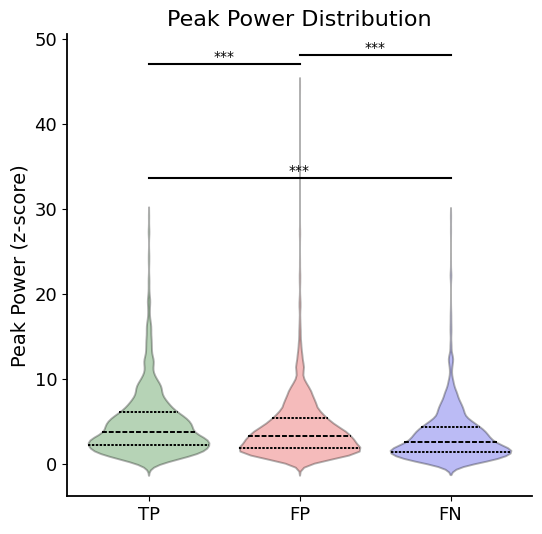

In [137]:
fig,ax=plot_power(vtype="Peak Power")
# fig.savefig("figures/peak_power_violin_plot2.svg")

C:\Users\NCN\AppData\Local\Temp\ipykernel_32728\1703575658.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Type', y=vtype, order=order, inner="quartile", ax=ax, palette=colors, alpha=0.3, linecolor="black", linewidth=1.4)


Statistical Significance (Mann-Whitney U Test) - Mean Power:
TP vs FP: Cliff's Delta = 0.157 (Small)
FP vs FN: Cliff's Delta = 0.100 (Negligible)
TP vs FN: Cliff's Delta = 0.242 (Small)
TP vs FP: p-value = 8.0582e-124 (***)
FP vs FN: p-value = 5.2528e-31 (***)
TP vs FN: p-value = 5.8191e-174 (***)


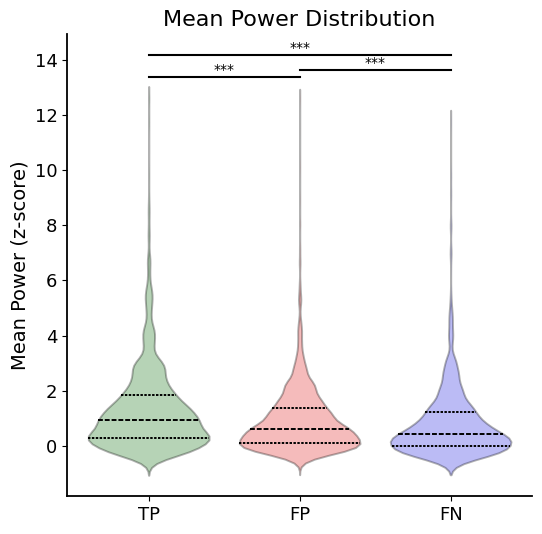

In [138]:
fig,ax=plot_power(vtype="Mean Power")
fig.savefig("figures/mean_power_violin_plot2.svg")

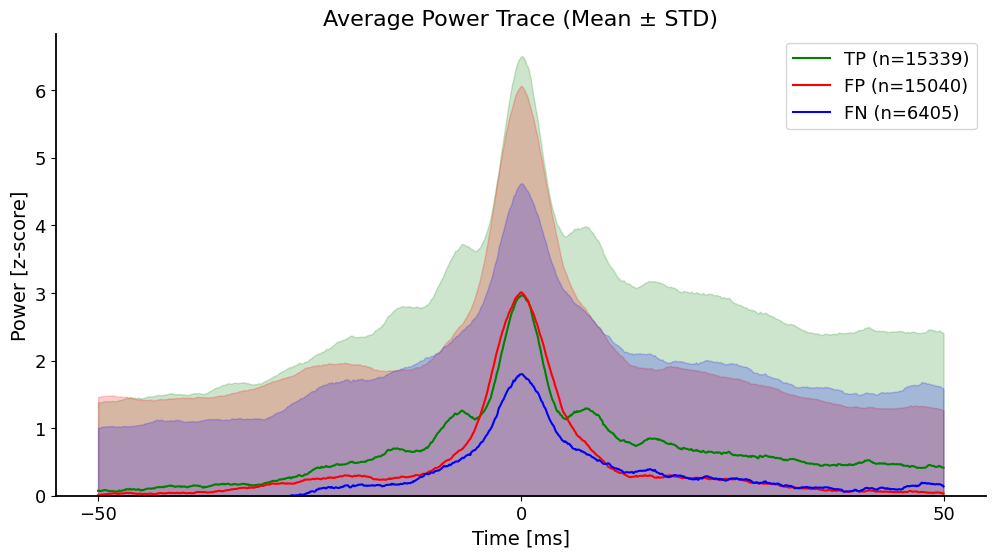

In [139]:
# 3. Power Trace Analysis (Whole Window)
if os.path.exists(DATA_FILE) and not df.empty:
    # Function to plot traces with CI
    def plot_traces(data_df, title_suffix=""):
        fig,ax=plt.subplots(figsize=(12,6))
        
        event_types = ['TP', 'FP', 'FN']
        colors = {'TP': 'green', 'FP': 'red', 'FN': 'blue'}
        
        # Check trace length from first record
        trace_len = len(data_df.iloc[0]['Trace'])

        x_axis = np.arange(trace_len)/10-50  # Convert to milliseconds, centered at 0
        
        for et in event_types:
            subset = data_df[data_df['Type'] == et]
            if subset.empty: continue
            
            # Stack traces: (N_samples, Time_points)
            traces = np.stack(subset['Trace'].values)
            
            # mean_trace = np.mean(traces, axis=0)
            mean_trace = np.median(traces, axis=0)
            std_trace = np.std(traces, axis=0)
            
            # 95% CI approx
            ci = 1.96 * std_trace / np.sqrt(len(traces))
            
            # Using STD for visualization as requested
            upper = mean_trace + std_trace
            lower = mean_trace - std_trace
            lower = np.maximum(lower, 0)
            
            ax.plot(x_axis, mean_trace, label=f'{et} (n={len(traces)})', color=colors[et])
            ax.fill_between(x_axis, lower, upper, color=colors[et], alpha=0.2)
            
        ax.set_title(f'Average Power Trace (Mean ± STD)',fontsize=16)
        ax.set_xlabel('Time [ms]', fontsize=14)
        ax.set_ylabel('Power [z-score]', fontsize=14)
        ax.legend(fontsize=13)
        # ax.grid(True, alpha=0.2)
        ax.grid(False)
        # ax.set_xticks(np.arange(-100, 101, 50))
        ax.set_xticks(np.arange(-50, 51, 50))
        ax.tick_params(axis='both', which='major', labelsize=13)
        ax.spines[['left', 'bottom', 'right', 'top']].set_linewidth(1.3)
        ax.spines[['right', 'top']].set_visible(False)
        ax.set_ylim(bottom=0)
        plt.show()
        return fig,ax

    # Plot aggregated across all networks/adapts
    fig,ax=plot_traces(df, title_suffix="(Aggregated)")
    fig.savefig("figures/power_traces_aggregated2.svg")

# Event Properties

In [140]:
# read csv with properties
properties_file=os.path.join(SPIKES_ROOT, filename_properties)
if os.path.exists(properties_file):
    properties_df = pd.read_csv(properties_file)
    print(f"Loaded properties from {properties_file}")
    display(properties_df.head())

Loaded properties from c:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples\snnTorch\generalization_madrid\data\power_analysis_properties_center_peak_100ms.csv


,Session,Network,Adapt,Event_Idx,Event_Type,Duration_ms,Preferred_Freq,Low_Freq_Contrib,Entropy,Spike_Number,Spike_Rate,Spike_Number_within_Event,Spike_Rate_within_Event
0,2025-09-22_17-55-26,adapt20_3b,20,0,TP,76.833333,130.0,0.866410,3.722694,37.0,370.0,0.0,0.0
1,2025-09-22_17-55-26,adapt20_3b,20,1,TP,56.633333,130.0,0.825112,3.978476,27.0,270.0,0.0,0.0
2,2025-09-22_17-55-26,adapt20_3b,20,2,TP,76.833333,160.0,0.903833,3.941669,38.0,380.0,0.0,0.0
3,2025-09-22_17-55-26,adapt20_3b,20,3,TP,39.700000,150.0,0.840425,3.670490,25.0,250.0,0.0,0.0
4,2025-09-22_17-55-26,adapt20_3b,20,4,TP,48.200000,120.0,0.909632,3.221000,34.0,340.0,0.0,0.0


In [141]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
import numpy as np

def plot_event_properties(df, 
                          properties=['Duration_ms', 'Preferred_Freq', 'Low_Freq_Contrib', 'Entropy', 'Spike_Rate', 'Spike_Rate_within_Event'],
                          x='Event_Type', 
                          hue=None, 
                          aggregate_by=None, 
                          order=None, 
                          hue_order=None,
                          title_suffix="",):
    """
    Plots properties of events with options for aggregation.
    
    Args:
        df: DataFrame containing the data.
        properties: List of column names to plot.
        x: Column for x-axis (e.g., 'Event_Type', 'Network').
        hue: Column for color grouping (e.g., 'Network').
        aggregate_by: List of columns to aggregate by (e.g. ['Session']). 
                      If provided, the data will be averaged over these groups (preserving x and hue).
                      If None, individual events are plotted.
    """
    df_plot = df.copy()
    
    # Define color scheme for Event Types
    colors = {'TP': 'green', 'FP': 'red', 'FN': 'blue'}
    palette = None
    
    # Determine appropriate palette
    if hue == 'Event_Type':
        palette = colors
    elif x == 'Event_Type' and hue is None:
        palette = colors

    # --- Aggregation ---
    if aggregate_by is not None:
        # Construct group keys: x, hue (if present), and aggregation columns
        group_keys = set(aggregate_by)
        if x in df_plot.columns: group_keys.add(x)
        if hue and hue in df_plot.columns: group_keys.add(hue)
        
        group_keys = list(group_keys)
        
        print(f"Aggregating data by {group_keys}...")
        
        # Select numeric columns for median
        numeric_cols = df_plot.select_dtypes(include=[np.number]).columns.tolist()
        
        # Groupby
        df_plot = df_plot.groupby(group_keys)[numeric_cols].median().reset_index()
        title_suffix += f" (Aggregated by {aggregate_by})"
    else:
        title_suffix += " (All Events)"

    # --- Plotting ---
    n_props = len(properties)
    fig, axes = plt.subplots(1, n_props, figsize=(4*n_props, 5))
    if n_props == 1: axes = [axes]
    
    for i, prop in enumerate(properties):
        if prop not in df_plot.columns:
            print(f"Skipping {prop} (not in columns)")
            continue
            
        ax = axes[i]
        
        # Plot
        sns.violinplot(data=df_plot, x=x, y=prop, hue=hue, order=order, hue_order=hue_order, ax=ax, inner="quart", alpha=0.3, cut=0, palette=palette)
        # sns.stripplot(data=df_plot, x=x, y=prop, hue=hue, order=order, hue_order=hue_order, dodge=True, ax=ax, alpha=0.6, jitter=True, size=4, legend=False, palette=palette)
        
        # --- Simple Stats (Mann-Whitney) for 2 groups ---
        # Only do stats if we have meaningful x grouping and no hue (comparing x bins)
        if hue is None and x in df_plot.columns:
            levels = order if order else sorted(df_plot[x].dropna().unique())
            if len(levels) == 2:
                g1 = df_plot[df_plot[x] == levels[0]][prop].dropna()
                g2 = df_plot[df_plot[x] == levels[1]][prop].dropna()
                if len(g1) > 0 and len(g2) > 0:
                    _, p = mannwhitneyu(g1, g2)
                    # Annotate
                    y_max = df_plot[prop].max()
                    ax.text(0.5, y_max, f"p={p:.4f}", ha='center', va='bottom', transform=ax.get_xaxis_transform())

        # ax.set_title(prop, fontsize=12)
        ax.set_xlabel(x)
        ax.set_ylabel(prop)
    
    plt.suptitle(f'Event Properties{title_suffix}', fontsize=14)
    plt.tight_layout()
    plt.show()
    return fig

Aggregating data by ['Network', 'Session', 'Event_Type']...


C:\Users\NCN\AppData\Local\Temp\ipykernel_32728\3171223375.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x=x, y=prop, hue=hue, order=order, hue_order=hue_order, ax=ax, inner="quart", alpha=0.3, cut=0, palette=palette)
C:\Users\NCN\AppData\Local\Temp\ipykernel_32728\3171223375.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x=x, y=prop, hue=hue, order=order, hue_order=hue_order, ax=ax, inner="quart", alpha=0.3, cut=0, palette=palette)
C:\Users\NCN\AppData\Local\Temp\ipykernel_32728\3171223375.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `l

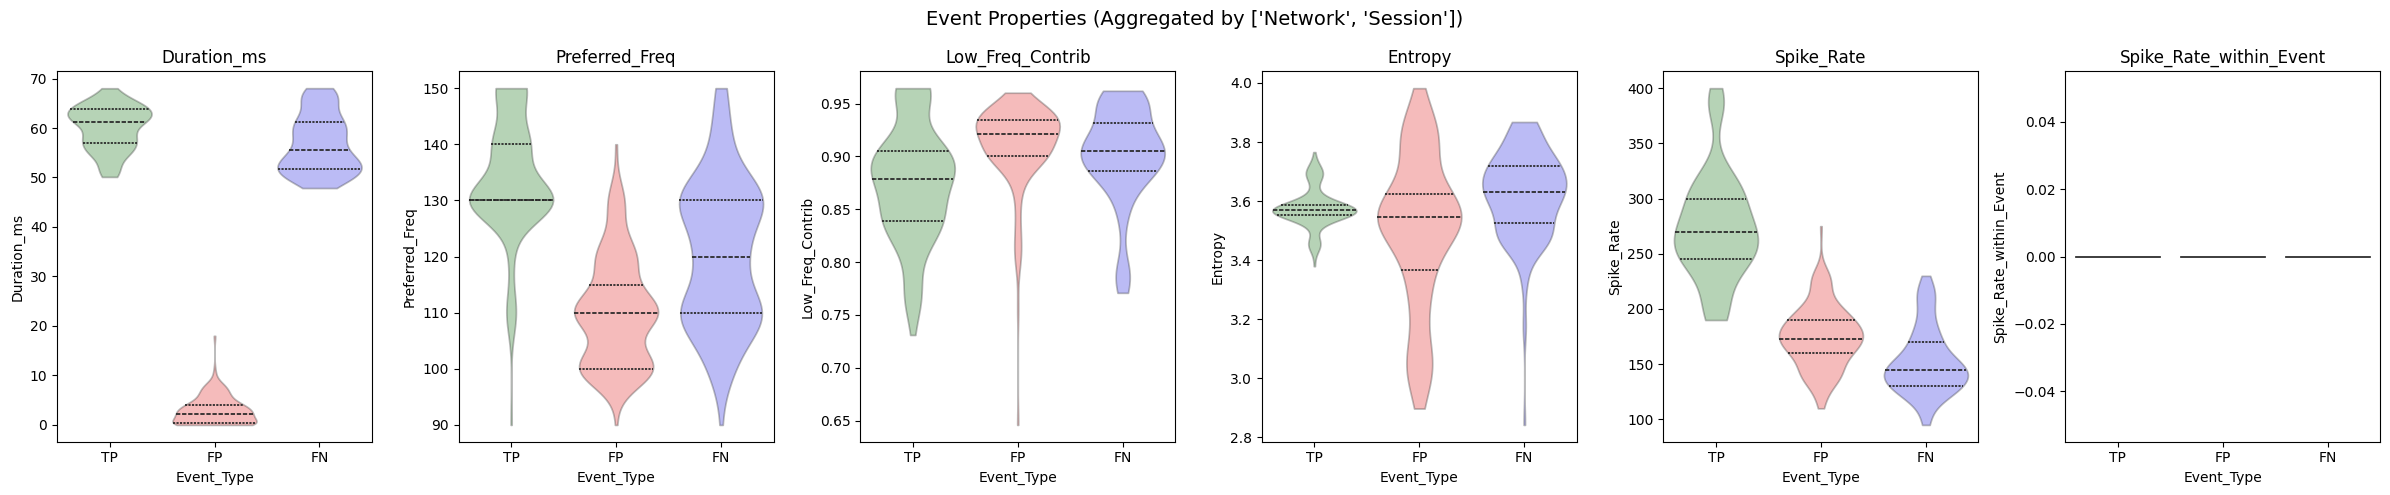

In [26]:
fig=plot_event_properties(properties_df, 
                        properties=['Duration_ms', 'Preferred_Freq', 'Low_Freq_Contrib', 'Entropy', 'Spike_Rate', 'Spike_Rate_within_Event'],
                        x='Event_Type', 
                        hue=None, 
                        aggregate_by=["Network","Session"], 
                        order=["TP", "FP", "FN"], 
                        hue_order=None,
                        title_suffix="",)

In [27]:
def get_property_summary_table(df, group_col="Event_Type", properties=None, aggregate_by=None):
    """
    Generates a summary table comparing groups in group_col.
    Supports aggregation via aggregate_by (e.g., ['Session']).
    
    Args:
        df: DataFrame containing the data.
        group_col: Column to group by for the summary columns (e.g. 'Event_Type' or 'Network').
        properties: List of properties to summarize. 
        aggregate_by: List of columns to aggregate (mean) by before summarizing. 
                      e.g. ['Session'] will compute the mean per session for each group in group_col, 
                      and then summarize the distribution of session means.
    """
    if properties is None:
        properties = ['Duration_ms', 'Preferred_Freq', 'Low_Freq_Contrib', 'Entropy', 'Spike_Rate', 'Spike_Rate_within_Event']

    df_plot = df.copy()

    # --- Aggregation ---
    if aggregate_by:
        group_keys = set(aggregate_by)
        if group_col in df_plot.columns: group_keys.add(group_col)
        group_keys = list(group_keys)
        print(f"Aggregating data by {group_keys}...")
        numeric_cols = df_plot.select_dtypes(include=[np.number]).columns.tolist()
        df_plot = df_plot.groupby(group_keys)[numeric_cols].mean().reset_index()

    # Get Groups
    if group_col not in df_plot.columns:
        print(f"Group column '{group_col}' not found.")
        return pd.DataFrame()
        
    groups = sorted(df_plot[group_col].dropna().unique())
    print(f"Comparing groups in '{group_col}': {groups}")

    summary_rows = []
    
    for prop in properties:
        if prop not in df_plot.columns: continue
        
        row_stats = {"Property": prop}
        group_vectors = {}

        for g in groups:
            data = df_plot[df_plot[group_col] == g][prop].dropna()
            group_vectors[g] = data
            
            median = data.median()
            std = data.std()
            count = len(data)
            row_stats[str(g)] = f"{median:.2f} ± {std:.2f} (n={count})"

        # Parameterized Stats (pairwise if 2 groups)
        if len(groups) == 2:
            g1, g2 = groups[0], groups[1]
            d1, d2 = group_vectors[g1], group_vectors[g2]
            if len(d1) > 0 and len(d2) > 0:
                _, p = mannwhitneyu(d1, d2)
                row_stats["p-value"] = p
            else:
                row_stats["p-value"] = np.nan
             
        summary_rows.append(row_stats)

    summary_df = pd.DataFrame(summary_rows)
    
    # Format p-value if exists
    if "p-value" in summary_df.columns:
        def format_p(p):
            if pd.isna(p): return "-"
            sig = ""
            if p < 0.05: sig = "*"
            if p < 0.01: sig = "**"
            if p < 0.001: sig = "***"
            if p < 0.001: return f"{p:.2e} {sig}"
            return f"{p:.4f} {sig}"
        summary_df["p-value (MWU)"] = summary_df["p-value"].apply(format_p)
        summary_df.drop(columns=["p-value"], inplace=True)
        
    return summary_df

get_property_summary_table(properties_df, group_col="Event_Type", properties=['Duration_ms', 'Preferred_Freq', 'Low_Freq_Contrib', 'Entropy', 'Spike_Rate', 'Spike_Rate_within_Event'], aggregate_by=["Network","Session"])

Aggregating data by ['Network', 'Session', 'Event_Type']...
Comparing groups in 'Event_Type': ['FN', 'FP', 'TP']


,Property,FN,FP,TP
0,Duration_ms,56.94 ± 6.27 (n=156),7.40 ± 3.65 (n=156),63.52 ± 4.49 (n=156)
1,Preferred_Freq,122.64 ± 9.67 (n=156),111.44 ± 8.14 (n=156),132.11 ± 8.40 (n=156)
2,Low_Freq_Contrib,0.89 ± 0.05 (n=156),0.91 ± 0.04 (n=156),0.85 ± 0.07 (n=156)
3,Entropy,3.64 ± 0.14 (n=156),3.52 ± 0.25 (n=156),3.56 ± 0.07 (n=156)
4,Spike_Rate,148.97 ± 29.61 (n=156),179.72 ± 27.23 (n=156),281.15 ± 45.27 (n=156)
5,Spike_Rate_within_Event,21.02 ± 42.74 (n=156),0.00 ± 55.82 (n=156),64.24 ± 40.16 (n=156)


# Single Property

In [142]:
from scipy.stats import mannwhitneyu, wilcoxon
import itertools

def plot_single_property(df, 
                         prop, 
                         x='Event_Type', 
                         hue=None, 
                         aggregate_by=None, 
                         order=None, 
                         hue_order=None,
                         title_suffix="",
                         ax=None,
                         y_label=None,
                         figsize=(6,6),y_lim=None, boxplot=False):
    """
    Plots a single property with detailed pairwise statistical comparisons.
    Uses Wilcoxon signed-rank test for aggregated (paired) data, and Mann-Whitney U for independent data.
    """
    df_plot = df.copy()
    
    # Define color scheme for Event Types
    colors = {'TP': 'green', 'FP': 'red', 'FN': 'blue'}
    palette = None
    if hue == 'Event_Type' or (x == 'Event_Type' and hue is None):
        palette = colors

    # --- Aggregation ---
    is_paired = False
    if aggregate_by is not None:
        group_keys = set(aggregate_by)
        if x in df_plot.columns: group_keys.add(x)
        if hue and hue in df_plot.columns: group_keys.add(hue)
        group_keys = list(group_keys)
        numeric_cols = df_plot.select_dtypes(include=[np.number]).columns.tolist()
        df_plot = df_plot.groupby(group_keys)[numeric_cols].median().reset_index()
        title_suffix += f" (Aggregated by {aggregate_by})"
        is_paired = True

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    # Plot
    if not boxplot:
        sns.violinplot(data=df_plot, x=x, y=prop, hue=hue, order=order, hue_order=hue_order, ax=ax, inner="quart", alpha=0.3, cut=0, palette=palette)
    else:
        sns.boxplot(data=df_plot, x=x, y=prop, hue=hue, order=order, hue_order=hue_order, ax=ax, palette=palette,boxprops=dict(alpha=.3),showfliers=False )
    if aggregate_by is not None:
        sns.stripplot(data=df_plot, x=x, y=prop, hue=hue, order=order, hue_order=hue_order, ax=ax, alpha=0.6, jitter=True, size=4, legend=False, palette=palette)

    # --- Statistical Testing (Pairwise) ---
    # Currently only implemented for 'x' categories when hue is None
    if hue is None and x in df_plot.columns:
        levels = order if order else sorted(df_plot[x].dropna().unique())
        n_levels = len(levels)
        
        if n_levels > 1:
            p_vals = []
            comparisons = []
            
            # Prepare heights for brackets based on the max value in each group
            # (Calculation repeated for visualization context, though not efficient)
            vectors_for_height = [df_plot[df_plot[x] == l][prop].dropna() for l in levels]
            centers = range(n_levels)
            heights = [v.max() if len(v) > 0 else 0 for v in vectors_for_height]

            # Generate all pairs
            for i, j in itertools.combinations(range(n_levels), 2):
                l1, l2 = levels[i], levels[j]
                
                p = np.nan
                stat_name = ""

                if is_paired:
                    # --- Wilcoxon Signed-Rank Test (Paired) ---
                    # Merge on aggregation keys to align subjects
                    merge_keys = [k for k in aggregate_by if k != x] if aggregate_by else []
                    
                    if merge_keys:
                        d1 = df_plot[df_plot[x] == l1]
                        d2 = df_plot[df_plot[x] == l2]
                        
                        # Inner merge ensures we only compare subjects present in both groups
                        merged = pd.merge(d1, d2, on=merge_keys, suffixes=('_1', '_2'), how='inner')
                        v1 = merged[prop + '_1'].dropna()
                        v2 = merged[prop + '_2'].dropna()
                        
                        if len(v1) > 0:
                            try:
                                # wilcoxon requires non-zero differences for valid p-value in some versions, 
                                # or throws error if inputs are empty
                                u, p = wilcoxon(v1, v2)
                                cliff_delta,effect=cliffs_delta(u, len(v1), len(v2))
                                print(f"{l1} vs {l2}: Cliff's Delta = {cliff_delta:.3f} ({effect})")
                            except ValueError:
                                # e.g. "zero_method 'wilcox' and 'pratt' do not work if x - y is zero for all elements."
                                p = 1.0 
                            stat_name = "Wilcox"
                else:
                    # --- Mann-Whitney U Test (Independent) ---
                    v1 = df_plot[df_plot[x] == l1][prop].dropna()
                    v2 = df_plot[df_plot[x] == l2][prop].dropna()
                    
                    if len(v1) > 0 and len(v2) > 0:
                        u, p = mannwhitneyu(v1, v2)
                        stat_name = "MWU"
                        cliff_delta,effect=cliffs_delta(u, len(v1), len(v2))
                        print(f"{l1} vs {l2}: Cliff's Delta = {cliff_delta:.3f} ({effect})")

                if not np.isnan(p):
                    p_vals.append(p)
                    # Label for debugging or printing
                    label = f"{l1} vs {l2} ({stat_name})"
                    comparisons.append((i, j, label))

            # Correction and plotting
            if p_vals:
                p_vals_adj = holm_bonferroni(p_vals)
                
                current_height_offset = 0
                max_h = max(heights) if heights else 0
                
                # Determine scaling for brackets
                y_min = df_plot[prop].min() if not df_plot.empty else 0
                y_max = df_plot[prop].max() if not df_plot.empty else 1
                y_range = y_max - y_min
                if y_range == 0: y_range = 1
                
                # Plot brackets
                for k, p_adj in enumerate(p_vals_adj):
                    idx1, idx2, label = comparisons[k]
                    print(f"{label}: p-value = {p_vals[k]:.4e} -> adj p-value = {p_adj:.4e}")

                    if p_adj < 0.05: # Only plot significant
                        # Find base height for this bracket (above the highest violin of the pair)
                        h_pair_max = max(heights[idx1], heights[idx2])
                        
                        # Stack: Base + fixed clearance + accumulated offset
                        h = h_pair_max + y_range*0.1 + current_height_offset
                        
                        # Annotate
                        sig = '***' if p_adj < 0.001 else '**' if p_adj < 0.01 else '*'
                        # print(f"  {label}: p={p_vals[k]:.4e} -> adj={p_adj:.4e} ({sig})")
                        
                        # barplot_annotate_brackets(idx1, idx2, p_adj, centers, [h]*n_levels, ax, barh=0.01, maxasterix=3)
                        
                        # Push next bracket up
                        current_height_offset += y_range * 0.12
                
                # Adjust final ylim to fit all brackets
                # ax.set_ylim(top=max_h + y_range*0.2 + current_height_offset)

    # ax.set_title(f'{prop} {title_suffix}', fontsize=12)
    ax.set_ylabel(f"{y_label}" if y_label else prop)
    ax.set_xlabel("")

    if y_lim is not None:
        ax.set_ylim(y_lim)

    ax.spines[['left', 'bottom', 'right', 'top']].set_linewidth(2)
    ax.spines[['right', 'top']].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=13)

    # ax.grid(True, alpha=0.1)
    ax.grid(False)
    plt.tight_layout()
    return fig



In [124]:
def get_single_property_summary(df, prop, group_col="Event_Type", aggregate_by=None):
    """
    Generates a detailed summary table for a single property, including Quartiles (25%-75%) and p-values.
    
    Args:
        df: DataFrame containing the data.
        prop: The property to summarize (e.g. 'Duration_ms').
        group_col: Column to group by (e.g. 'Event_Type').
        aggregate_by: List of columns to aggregate (mean) by before summarizing. 
    """
    df_plot = df.copy()

    # --- Aggregation ---
    is_paired = False
    if aggregate_by:
        group_keys = set(aggregate_by)
        if group_col in df_plot.columns: group_keys.add(group_col)
        group_keys = list(group_keys)
        numeric_cols = df_plot.select_dtypes(include=[np.number]).columns.tolist()
        df_plot = df_plot.groupby(group_keys)[numeric_cols].median().reset_index()
        is_paired = True
        print(f"Aggregating by {aggregate_by} -> N={len(df_plot)}")

    if prop not in df_plot.columns:
        print(f"Property '{prop}' not found.")
        return pd.DataFrame()
        
    groups = sorted(df_plot[group_col].unique())
    
    # 1. Descriptive Stats Rows
    stats_data = []
    
    for g in groups:
        data = df_plot[df_plot[group_col] == g][prop].dropna()
        
        q25 = data.quantile(0.25)
        median = data.median()
        q75 = data.quantile(0.75)
        mean = data.mean() # Optional
        std = data.std()
        n = len(data)
        
        stats_data.append({
            "Group": g,
            "Median [IQR]": f"{median:.2f} [{q25:.2f}, {q75:.2f}]",
            "Mean ± Std": f"{mean:.2f} ± {std:.2f}",
            "N": n
        })
        
    summary_df = pd.DataFrame(stats_data)
    
    # 2. Pairwise Comparisons
    # Add columns for each pair comparison p-value
    import itertools
    pairs = list(itertools.combinations(groups, 2))
    p_vals_dict = {}

    for g1, g2 in pairs:
        label = f"p({g1} vs {g2})"
        p = np.nan
        
        if is_paired:
            # Paired -> Wilcoxon
            merge_keys = [k for k in aggregate_by if k != group_col] if aggregate_by else []
            if merge_keys:
                d1 = df_plot[df_plot[group_col] == g1]
                d2 = df_plot[df_plot[group_col] == g2]
                merged = pd.merge(d1, d2, on=merge_keys, suffixes=('_1', '_2'), how='inner')
                v1 = merged[prop + '_1'].dropna()
                v2 = merged[prop + '_2'].dropna()
                
                if len(v1) > 0:
                    try:
                        _, p = wilcoxon(v1, v2)
                    except ValueError:
                        p = 1.0
        else:
             # Independent -> Mann-Whitney
            v1 = df_plot[df_plot[group_col] == g1][prop].dropna()
            v2 = df_plot[df_plot[group_col] == g2][prop].dropna()
            if len(v1) > 0 and len(v2) > 0:
                _, p = mannwhitneyu(v1, v2)
        
        p_vals_dict[label] = p

    # Format P-values
    p_text_dict = {}
    for k, p in p_vals_dict.items():
         if pd.isna(p):
             p_text_dict[k] = "-"
         else:
             sig = ""
             if p < 0.05: sig = "*"
             if p < 0.01: sig = "**"
             if p < 0.001: sig = "***"
             
             if p < 0.001:
                 p_text_dict[k] = f"{p:.2e} {sig}"
             else:
                 p_text_dict[k] = f"{p:.4f} {sig}"
    
    
    
    # Alternatively, create a square matrix or just descriptive table + list of p-values
    display(summary_df)
    
    print("\n--- Pairwise Comparisons ---")
    comparisons_df = pd.DataFrame([p_text_dict])
    display(comparisons_df)
    
    return summary_df, comparisons_df

In [143]:

aggregate_by=None
order=["TP", "FP", "FN"]
figsize=(5,6)

### Duration_ms


C:\Users\NCN\AppData\Local\Temp\ipykernel_32728\656608900.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x=x, y=prop, hue=hue, order=order, hue_order=hue_order, ax=ax, inner="quart", alpha=0.3, cut=0, palette=palette)


TP vs FP: Cliff's Delta = 0.982 (Large)
TP vs FN: Cliff's Delta = 0.162 (Small)
FP vs FN: Cliff's Delta = -0.974 (Large)
TP vs FP (MWU): p-value = 0.0000e+00 -> adj p-value = 0.0000e+00
TP vs FN (MWU): p-value = 7.0333e-79 -> adj p-value = 7.0333e-79
FP vs FN (MWU): p-value = 0.0000e+00 -> adj p-value = 0.0000e+00


,Group,Median [IQR],Mean ± Std,N
0,FN,"56.00 [48.17, 65.10]",58.20 ± 16.45,6405
1,FP,"3.00 [0.00, 13.00]",9.45 ± 13.10,15056
2,TP,"59.90 [50.80, 70.30]",62.49 ± 17.41,15339



--- Pairwise Comparisons ---


,p(FN vs FP),p(FN vs TP),p(FP vs TP)
0,0.00e+00 ***,7.03e-79 ***,0.00e+00 ***


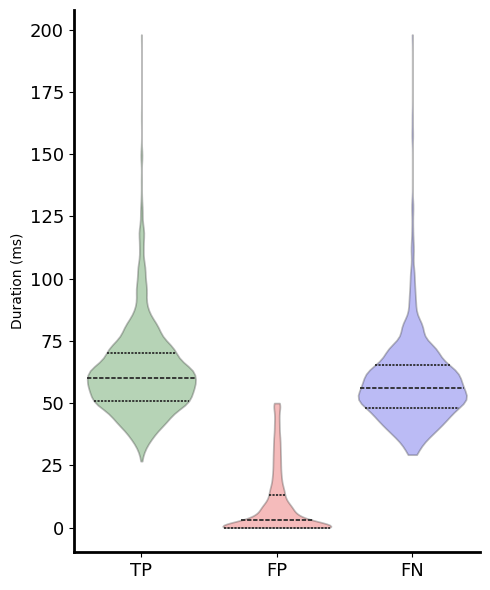

In [144]:
# Example Usage:
property='Duration_ms'
y_label="Duration (ms)"
y_lim=None
# y_lim=(-1,200)
fig=plot_single_property(properties_df, property, x='Event_Type', aggregate_by=aggregate_by, order=order, y_label=y_label, y_lim=y_lim, figsize=figsize)
summary_df, comparisons_df=get_single_property_summary(properties_df, property, group_col="Event_Type", aggregate_by=aggregate_by)

# Preferred Frequency

TP vs FP: Cliff's Delta = 0.494 (Large)
TP vs FN: Cliff's Delta = 0.286 (Small)
FP vs FN: Cliff's Delta = -0.200 (Small)
TP vs FP (MWU): p-value = 0.0000e+00 -> adj p-value = 0.0000e+00
TP vs FN (MWU): p-value = 6.5474e-248 -> adj p-value = 1.3095e-247
FP vs FN (MWU): p-value = 4.4828e-121 -> adj p-value = 4.4828e-121


C:\Users\NCN\AppData\Local\Temp\ipykernel_32728\656608900.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x=x, y=prop, hue=hue, order=order, hue_order=hue_order, ax=ax, palette=palette,boxprops=dict(alpha=.3),showfliers=False )


,Group,Median [IQR],Mean ± Std,N
0,FN,"120.00 [100.00, 140.00]",119.69 ± 28.17,6405
1,FP,"110.00 [90.00, 130.00]",110.93 ± 26.60,15056
2,TP,"130.00 [120.00, 150.00]",131.76 ± 22.87,15339



--- Pairwise Comparisons ---


,p(FN vs FP),p(FN vs TP),p(FP vs TP)
0,4.48e-121 ***,6.55e-248 ***,0.00e+00 ***


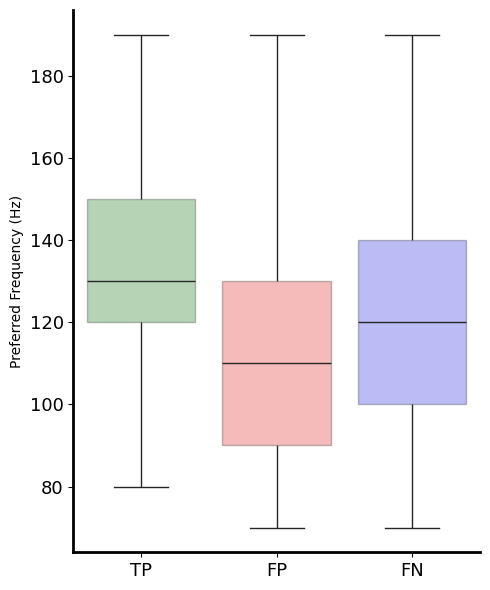

In [145]:
# Example Usage:
properties=['Duration_ms', 'Preferred_Freq', 'Low_Freq_Contrib', 'Entropy', 'Spike_Rate', 'Spike_Rate_within_Event']
property='Preferred_Freq'
y_label="Preferred Frequency (Hz)"
y_lim=None
boxplot=True
# y_lim=(80,160)
fig=plot_single_property(properties_df, property, x='Event_Type', aggregate_by=aggregate_by, order=order, y_label=y_label, y_lim=y_lim, figsize=figsize,boxplot=boxplot)
summary_df, comparisons_df=get_single_property_summary(properties_df, property, group_col="Event_Type", aggregate_by=aggregate_by)

### Low Frequency Contribution

C:\Users\NCN\AppData\Local\Temp\ipykernel_32728\656608900.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x=x, y=prop, hue=hue, order=order, hue_order=hue_order, ax=ax, inner="quart", alpha=0.3, cut=0, palette=palette)


TP vs FP: Cliff's Delta = -0.418 (Medium)
TP vs FN: Cliff's Delta = -0.301 (Small)
FP vs FN: Cliff's Delta = 0.091 (Negligible)
TP vs FP (MWU): p-value = 0.0000e+00 -> adj p-value = 0.0000e+00
TP vs FN (MWU): p-value = 3.2938e-268 -> adj p-value = 6.5876e-268
FP vs FN (MWU): p-value = 2.4845e-26 -> adj p-value = 2.4845e-26


,Group,Median [IQR],Mean ± Std,N
0,FN,"0.91 [0.84, 0.95]",0.88 ± 0.11,6405
1,FP,"0.92 [0.88, 0.95]",0.90 ± 0.07,15056
2,TP,"0.86 [0.77, 0.92]",0.83 ± 0.13,15339



--- Pairwise Comparisons ---


,p(FN vs FP),p(FN vs TP),p(FP vs TP)
0,2.48e-26 ***,3.29e-268 ***,0.00e+00 ***


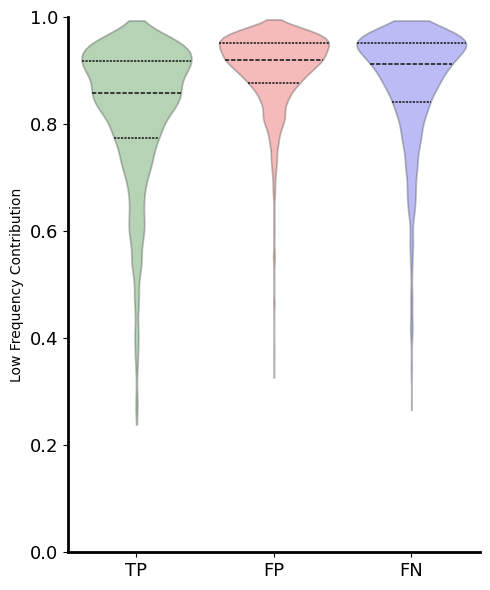

In [146]:
# Example Usage:
property='Low_Freq_Contrib'
y_label="Low Frequency Contribution"
y_lim=(0,1)
fig=plot_single_property(properties_df, property, x='Event_Type', aggregate_by=aggregate_by, order=order, y_label=y_label, y_lim=y_lim, figsize=figsize)
summary_df, comparisons_df=get_single_property_summary(properties_df, property, group_col="Event_Type", aggregate_by=aggregate_by)

### Spectral Entropy

C:\Users\NCN\AppData\Local\Temp\ipykernel_32728\567788911.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x=x, y=prop, hue=hue, order=order, hue_order=hue_order, ax=ax, inner="quart", alpha=0.3, cut=0, palette=palette)


TP vs FP (MWU): p-value = 2.1029e-192 -> adj p-value = 6.3087e-192
TP vs FN (MWU): p-value = 1.5341e-20 -> adj p-value = 1.5341e-20
FP vs FN (MWU): p-value = 5.0665e-180 -> adj p-value = 1.0133e-179


,Group,Median [IQR],Mean ± Std,N
0,FN,"3.63 [3.38, 3.86]",3.60 ± 0.36,6405
1,FP,"3.47 [3.11, 3.74]",3.40 ± 0.48,15056
2,TP,"3.58 [3.38, 3.77]",3.56 ± 0.30,15339



--- Pairwise Comparisons ---


,p(FN vs FP),p(FN vs TP),p(FP vs TP)
0,5.07e-180 ***,1.53e-20 ***,2.10e-192 ***


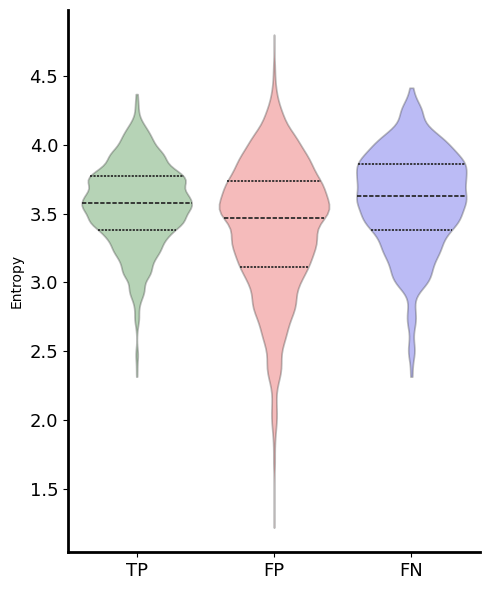

In [130]:
property='Entropy'
y_label="Entropy"

fig=plot_single_property(properties_df, property, x='Event_Type', aggregate_by=aggregate_by, order=order, y_label=y_label,figsize=figsize)
summary_df, comparisons_df=get_single_property_summary(properties_df, property, group_col="Event_Type", aggregate_by=aggregate_by)

### Spike Rate

C:\Users\NCN\AppData\Local\Temp\ipykernel_32728\567788911.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x=x, y=prop, hue=hue, order=order, hue_order=hue_order, ax=ax, inner="quart", alpha=0.3, cut=0, palette=palette)


TP vs FP (MWU): p-value = 0.0000e+00 -> adj p-value = 0.0000e+00
TP vs FN (MWU): p-value = 0.0000e+00 -> adj p-value = 0.0000e+00
FP vs FN (MWU): p-value = 1.3533e-196 -> adj p-value = 1.3533e-196


,Group,Median [IQR],Mean ± Std,N
0,FN,"150.00 [100.00, 190.00]",153.20 ± 66.59,6405
1,FP,"180.00 [130.00, 230.00]",187.21 ± 83.03,15056
2,TP,"270.00 [210.00, 350.00]",289.15 ± 104.84,15339



--- Pairwise Comparisons ---


,p(FN vs FP),p(FN vs TP),p(FP vs TP)
0,1.35e-196 ***,0.00e+00 ***,0.00e+00 ***


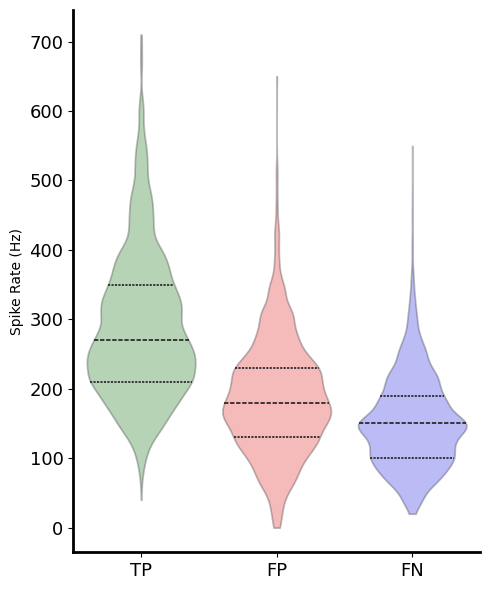

In [131]:
property="Spike_Rate"
y_label="Spike Rate (Hz)"

fig=plot_single_property(properties_df, property, x='Event_Type', aggregate_by=aggregate_by, order=order, y_label=y_label,figsize=figsize)
summary_df, comparisons_df=get_single_property_summary(properties_df, property, group_col="Event_Type", aggregate_by=aggregate_by)

C:\Users\NCN\AppData\Local\Temp\ipykernel_32728\567788911.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x=x, y=prop, hue=hue, order=order, hue_order=hue_order, ax=ax, inner="quart", alpha=0.3, cut=0, palette=palette)


TP vs FP (MWU): p-value = 0.0000e+00 -> adj p-value = 0.0000e+00
TP vs FN (MWU): p-value = 0.0000e+00 -> adj p-value = 0.0000e+00
FP vs FN (MWU): p-value = 1.3533e-196 -> adj p-value = 1.3533e-196


,Group,Median [IQR],Mean ± Std,N
0,FN,"15.00 [10.00, 19.00]",15.32 ± 6.66,6405
1,FP,"18.00 [13.00, 23.00]",18.72 ± 8.30,15056
2,TP,"27.00 [21.00, 35.00]",28.92 ± 10.48,15339



--- Pairwise Comparisons ---


,p(FN vs FP),p(FN vs TP),p(FP vs TP)
0,1.35e-196 ***,0.00e+00 ***,0.00e+00 ***


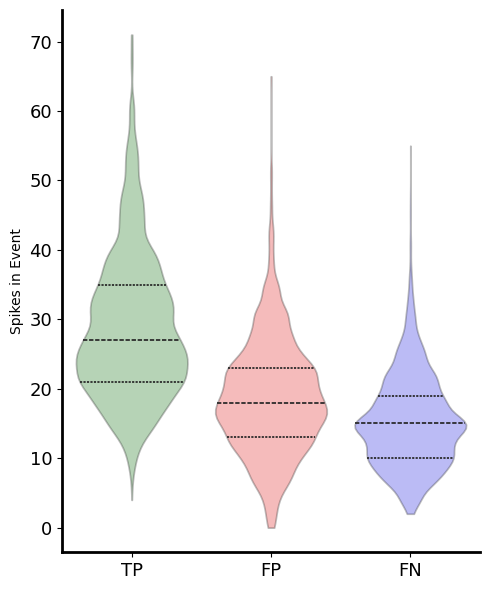

In [132]:
# Spike Number 
property="Spike_Number"
y_label="Spikes in Event"

fig=plot_single_property(properties_df, property, x='Event_Type', aggregate_by=aggregate_by, order=order, y_label=y_label,figsize=figsize)
summary_df, comparisons_df=get_single_property_summary(properties_df, property, group_col="Event_Type", aggregate_by=aggregate_by)